# Gaussian mean and covariance decomposition

This notebook reproduces the Gaussian decomposition example. Each observation
is a diagonal Gaussian measure with a random mean and random scale.

For this family, squared Wasserstein distance separates into Euclidean
differences of means and standard deviations. Metric variance therefore splits
into mean and covariance components.

In [1]:
from pathlib import Path
import sys

candidate = Path.cwd().resolve()
if (candidate / "src").is_dir():
    PUBLIC_ROOT = candidate
elif (candidate.parent / "src").is_dir():
    PUBLIC_ROOT = candidate.parent
else:
    raise RuntimeError("Start Jupyter in public or public/notebooks.")

sys.path.insert(0, str(PUBLIC_ROOT / "src"))
DATA_DIR = PUBLIC_ROOT / "data"
print(f"Public package: {PUBLIC_ROOT.name}")

Public package: public


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

from bmu.simulation_core import complete_component_estimates

plt.style.use("seaborn-v0_8-whitegrid")
PAPER_SCALE = False

## One realization

The left panel draws one sampled population of Gaussian measures. The right
panel reports its estimated decomposition with regular confidence intervals.

Crosses mark the analytic population targets. The simulation design matches
the manuscript, while this realization remains random under the fixed seed.

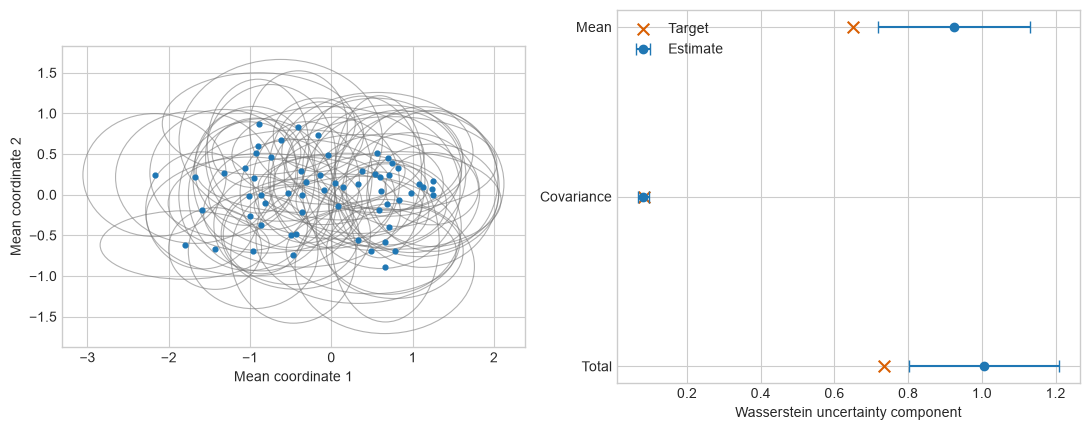

In [3]:
rng = np.random.default_rng(20260714)
n_visual = 60
means = np.column_stack(
    [rng.normal(0.0, 0.7, n_visual), rng.normal(0.0, 0.4, n_visual)]
)
sds = np.column_stack(
    [
        0.9 + 0.4 * rng.uniform(-1.0, 1.0, n_visual),
        0.7 + 0.3 * rng.uniform(-1.0, 1.0, n_visual),
    ]
)

names = ["Mean", "Covariance", "Total"]
arrays = [means, sds, np.column_stack([means, sds])]
targets = np.array([0.7**2 + 0.4**2, (0.4**2 + 0.3**2) / 3.0])
targets = np.append(targets, targets.sum())
estimates, standard_errors = zip(
    *(complete_component_estimates(values) for values in arrays)
)
estimates = np.asarray(estimates)
standard_errors = np.asarray(standard_errors)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for mean, sd in zip(means, sds):
    axes[0].add_patch(
        Ellipse(
            mean,
            width=2.0 * sd[0],
            height=2.0 * sd[1],
            fill=False,
            color="0.45",
            alpha=0.55,
            linewidth=0.8,
        )
    )
axes[0].scatter(means[:, 0], means[:, 1], s=12, color="#1f77b4", zorder=3)
axes[0].set(xlabel="Mean coordinate 1", ylabel="Mean coordinate 2")
axes[0].autoscale()
axes[0].set_aspect("equal", adjustable="box")

y = np.arange(3)
axes[1].errorbar(
    estimates,
    y,
    xerr=1.96 * standard_errors,
    fmt="o",
    capsize=4,
    color="#1f77b4",
    label="Estimate",
)
axes[1].scatter(targets, y, marker="x", s=70, color="#d95f02", label="Target")
axes[1].set(yticks=y, yticklabels=names, xlabel="Wasserstein uncertainty component")
axes[1].invert_yaxis()
axes[1].legend(frameon=False)
fig.tight_layout()
plt.show()

## Monte Carlo check

The quick setting uses fewer replications and a smaller outer sample. Set
`PAPER_SCALE` to `True` to use the manuscript settings.

The stored table below contains the paper-scale run. It is displayed separately
so that a quick run is never mistaken for the archived result.

In [4]:
def run_decomposition(n, repetitions, seed=20260714):
    rng = np.random.default_rng(seed)
    target = {
        "mean": 0.7**2 + 0.4**2,
        "covariance": (0.4**2 + 0.3**2) / 3.0,
    }
    target["total"] = target["mean"] + target["covariance"]
    stored = {name: {"estimate": [], "se": []} for name in target}

    for _ in range(repetitions):
        mean = np.column_stack(
            [rng.normal(0.0, 0.7, n), rng.normal(0.0, 0.4, n)]
        )
        sd = np.column_stack(
            [
                0.9 + 0.4 * rng.uniform(-1.0, 1.0, n),
                0.7 + 0.3 * rng.uniform(-1.0, 1.0, n),
            ]
        )
        values = {
            "mean": mean,
            "covariance": sd,
            "total": np.column_stack([mean, sd]),
        }
        for name, array in values.items():
            estimate, se = complete_component_estimates(array)
            stored[name]["estimate"].append(estimate)
            stored[name]["se"].append(se)

    rows = []
    for name, truth in target.items():
        estimate = np.asarray(stored[name]["estimate"])
        se = np.asarray(stored[name]["se"])
        rows.append(
            {
                "component": name,
                "target": truth,
                "mean_estimate": estimate.mean(),
                "bias": estimate.mean() - truth,
                "coverage": np.mean(
                    (estimate - 1.96 * se <= truth)
                    & (truth <= estimate + 1.96 * se)
                ),
                "repetitions": repetitions,
            }
        )
    return pd.DataFrame(rows)


n = 200 if PAPER_SCALE else 120
repetitions = 3_000 if PAPER_SCALE else 400
fresh_results = run_decomposition(n, repetitions)
fresh_results.round(4)

,component,target,mean_estimate,bias,coverage,repetitions
0,mean,0.6500,0.6503,0.0003,0.9350,400
1,covariance,0.0833,0.0835,0.0002,0.9725,400
2,total,0.7333,0.7337,0.0004,0.9350,400


In [5]:
paper_results = pd.read_csv(DATA_DIR / "simulation_decomposition.csv")
paper_results.round(4)

,component,target,mean_estimate,bias,rmse,coverage,mean_interval_length,repetitions
0,mean,0.6500,0.6504,0.0004,0.0512,0.9437,0.2007,3000
1,covariance,0.0833,0.0833,-0.0000,0.0038,0.9527,0.0153,3000
2,total,0.7333,0.7337,0.0004,0.0514,0.9443,0.2013,3000


The component estimates center near their analytic targets. Their sum matches
the total because diagonal Gaussian transport decomposes exactly in these
coordinates.